# Figure 4.2 — Flow-regime typology map with chapter-wide colour grammar

This notebook regenerates the 2011–2021 Frame A typology map using `flow_yee_palette_v2.py`.

- Cascade-led: warm red
- Counter-led: cool blue (no purple)
- Symmetric and Lateral: neutral greys

The analytical classifications are unchanged; only the visual encoding is updated.

In [2]:
from pathlib import Path
import importlib.util

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pyprojroot import here
import sys, os

# ------------------------------------------------------------------
# Project paths
# ------------------------------------------------------------------
ROOT = here()

sys.path.insert(0, str(ROOT))
from map_utils import load_london_msoa, plot_london_categorical


DATA_DIR = ROOT / "outputs"
GEO_PATH = ROOT / "data/london_msoa_2011.geojson"
OUTPUT_DIR = ROOT / "outputs/rerun_eda_figs_20260625"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "msoa_cascade_features_enriched_20260625.csv"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 11,
})

In [3]:
# ------------------------------------------------------------------
# Load the shared palette
# ------------------------------------------------------------------
palette_path = ROOT / "flow_yee_palette_v2.py"

spec = importlib.util.spec_from_file_location("flow_yee_palette_v2", palette_path)
palette = importlib.util.module_from_spec(spec)
if spec.loader is None:
    raise ImportError(f"Could not load palette module from {palette_path}")
spec.loader.exec_module(palette)

FLOW_FILL = palette.FLOW_FILL

# Coarse typology colours derived from the chapter-wide grammar.
# Symmetric and Lateral both belong to the neutral background family,
# but are kept visually distinct here.
TYPOLOGY_COLORS = {
    "Cascade-led": FLOW_FILL["inflow-driven"],  # warm red
    "Counter-led": FLOW_FILL["counter"],        # cool blue
    "Symmetric": FLOW_FILL["other"],            # neutral grey
    "Lateral": "#f6f5f3",                       # lighter neutral grey
}

TYPOLOGY_ORDER = [
    "Cascade-led",
    "Counter-led",
    "Symmetric",
    "Lateral",
]

print(f"Palette loaded from: {palette_path}")
print("Typology colours:")
for label in TYPOLOGY_ORDER:
    print(f"  {label:<13} {TYPOLOGY_COLORS[label]}")

Palette loaded from: /Users/xing/Desktop/CASA/dissertation/flow_yee_palette_v2.py
Typology colours:
  Cascade-led   #99000d
  Counter-led   #9db8ce
  Symmetric     #e9e7e2
  Lateral       #f6f5f3


In [4]:
# # ------------------------------------------------------------------
# # Load the shared palette
# # ------------------------------------------------------------------
# # Preferred project filename:
# #     ROOT / "flow_yee_palette_v2.py"
# #
# # The fallback supports the uploaded filename used in this chat.
# palette_candidates = [
#     ROOT / "flow_yee_palette_v2.py",
#     ROOT / "flow_yee_palette_v2(3).py",
#     Path("/mnt/data/flow_yee_palette_v2(3).py"),
# ]

# palette_path = next((p for p in palette_candidates if p.exists()), None)
# if palette_path is None:
#     raise FileNotFoundError(
#         "Could not find flow_yee_palette_v2.py. "
#         "Place it in the project root or update palette_candidates."
#     )

# spec = importlib.util.spec_from_file_location("flow_yee_palette_v2", palette_path)
# palette = importlib.util.module_from_spec(spec)
# if spec.loader is None:
#     raise ImportError(f"Could not load palette module from {palette_path}")
# spec.loader.exec_module(palette)

# FLOW_FILL = palette.FLOW_FILL

# # Coarse typology colours derived from the chapter-wide grammar.
# #
# # The palette intentionally groups Symmetric and Lateral as neutral
# # background fabric. This map still needs to distinguish the two
# # analytical categories, so Lateral uses a lighter neutral tint.
# TYPOLOGY_COLORS = {
#     "Cascade-led": FLOW_FILL["inflow-driven"],  # warm red
#     "Counter-led": FLOW_FILL["counter"],        # cool blue
#     "Symmetric": FLOW_FILL["other"],            # neutral grey
#     "Lateral": "#f6f5f3",                       # lighter neutral grey
# }

# TYPOLOGY_ORDER = [
#     "Cascade-led",
#     "Counter-led",
#     "Symmetric",
#     "Lateral",
# ]

# print(f"Palette loaded from: {palette_path}")
# print("Typology colours:")
# for label in TYPOLOGY_ORDER:
#     print(f"  {label:<13} {TYPOLOGY_COLORS[label]}")

In [5]:
# ------------------------------------------------------------------
# Load data and construct the typology if labels are not already saved
# ------------------------------------------------------------------
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} MSOAs from {DATA_PATH.name}")

def assign_typology(
    row,
    yr,
    cds_threshold,
    dom_upper=0.52,
    dom_lower=0.48,
):
    dom = row[f"Cascade_Dominance_{yr}"]
    cds = row[f"Cross_Decile_Share_{yr}"]

    if pd.isna(dom) or pd.isna(cds):
        return pd.NA
    if cds < cds_threshold:
        return "Lateral"
    if dom > dom_upper:
        return "Cascade-led"
    if dom < dom_lower:
        return "Counter-led"
    return "Symmetric"

for yr in ("11", "21"):
    typology_col = f"Typology_{yr}"

    if typology_col not in df.columns:
        cds_col = f"Cross_Decile_Share_{yr}"
        cds_threshold = df[cds_col].quantile(0.25)

        df[typology_col] = df.apply(
            assign_typology,
            axis=1,
            yr=yr,
            cds_threshold=cds_threshold,
        )

        print(
            f"Constructed {typology_col}; "
            f"25th-percentile threshold = {cds_threshold:.4f}"
        )

    unexpected = set(df[typology_col].dropna().unique()) - set(TYPOLOGY_ORDER)
    if unexpected:
        raise ValueError(
            f"Unexpected labels in {typology_col}: {sorted(unexpected)}"
        )

    print(f"\n20{yr} counts:")
    print(
        df[typology_col]
        .value_counts()
        .reindex(TYPOLOGY_ORDER, fill_value=0)
        .to_string()
    )

Loaded 982 MSOAs from msoa_cascade_features_enriched_20260625.csv
Constructed Typology_11; 25th-percentile threshold = 0.7825

2011 counts:
Typology_11
Cascade-led    129
Counter-led    339
Symmetric      268
Lateral        246
Constructed Typology_21; 25th-percentile threshold = 0.7924

2021 counts:
Typology_21
Cascade-led     76
Counter-led    416
Symmetric      244
Lateral        246


In [6]:
# ------------------------------------------------------------------
# Join typology labels to the harmonised 2011 MSOA geography
# ------------------------------------------------------------------
gdf = load_london_msoa(GEO_PATH, df)

required_cols = {"Typology_11", "Typology_21", "geometry"}
missing = required_cols - set(gdf.columns)
if missing:
    raise KeyError(f"Missing required columns after spatial join: {sorted(missing)}")

print(f"Mapped geography contains {len(gdf):,} MSOAs")

Mapped geography contains 983 MSOAs


In [7]:
# # ------------------------------------------------------------------
# # Generate the revised two-panel map
# # ------------------------------------------------------------------
# fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# for ax, yr in zip(axes, ("11", "21")):
#     plot_london_categorical(
#         gdf,
#         column=f"Typology_{yr}",
#         title=f"MSOA Flow Regime Typology (20{yr})",
#         color_dict=TYPOLOGY_COLORS,
#         category_order=TYPOLOGY_ORDER,
#         ax=ax,
#     )

#     # map_utils may create a panel-level legend; use one shared legend.
#     panel_legend = ax.get_legend()
#     if panel_legend is not None:
#         panel_legend.remove()

# legend_handles = [
#     mpatches.Patch(
#         facecolor=TYPOLOGY_COLORS[label],
#         edgecolor="#777777",
#         linewidth=0.4,
#         label=label,
#     )
#     for label in TYPOLOGY_ORDER
# ]

# fig.legend(
#     handles=legend_handles,
#     title="Typology",
#     loc="lower center",
#     bbox_to_anchor=(0.5, 0.015),
#     ncol=4,
#     fontsize=11,
#     title_fontsize=12,
#     frameon=False,
#     handlelength=1.8,
#     columnspacing=1.8,
# )

# fig.subplots_adjust(bottom=0.12, wspace=0.03)

# png_path = OUTPUT_DIR / "fig_14_typology_map_flow_yee_palette_v2.png"
# pdf_path = OUTPUT_DIR / "fig_14_typology_map_flow_yee_palette_v2.pdf"

# fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
# fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
# plt.show()

# print(f"Saved PNG: {png_path}")
# print(f"Saved PDF: {pdf_path}")

/Users/xing/Desktop/CASA/dissertation/map_utils.py:210: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/map_utils.py:210: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/map_utils.py:210: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/map_utils.py:210: UserWarning:

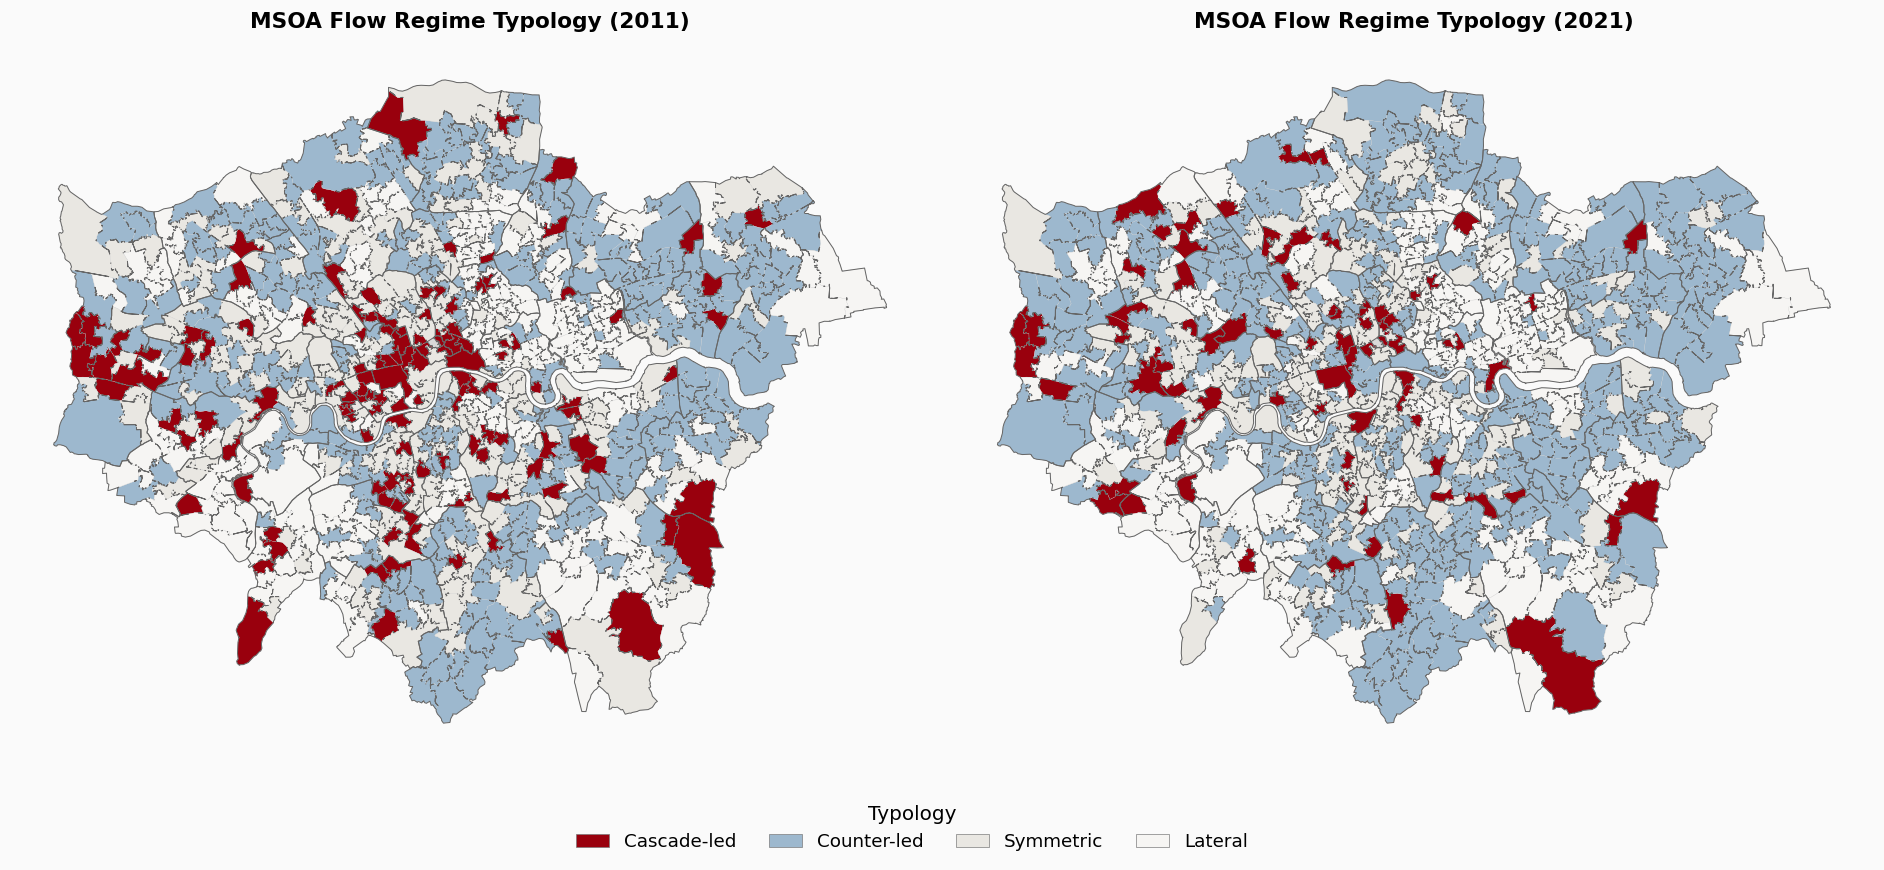

Saved PNG: /Users/xing/Desktop/CASA/dissertation/outputs/rerun_eda_figs_20260625/fig_14_typology_map_flow_yee_palette_v2.png


In [8]:
# ------------------------------------------------------------------
# Generate the revised two-panel map
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, yr in zip(axes, ("11", "21")):
    plot_london_categorical(
        gdf,
        column=f"Typology_{yr}",
        title=f"MSOA Flow Regime Typology (20{yr})",
        color_dict=TYPOLOGY_COLORS,
        ax=ax,
    )

    panel_legend = ax.get_legend()
    if panel_legend is not None:
        panel_legend.remove()

legend_handles = [
    mpatches.Patch(
        facecolor=TYPOLOGY_COLORS[label],
        edgecolor="#777777",
        linewidth=0.4,
        label=label,
    )
    for label in TYPOLOGY_ORDER
]

fig.legend(
    handles=legend_handles,
    title="Typology",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=4,
    fontsize=11,
    title_fontsize=12,
    frameon=False,
    handlelength=1.8,
    columnspacing=1.8,
)

fig.subplots_adjust(bottom=0.12, wspace=0.03)

png_path = OUTPUT_DIR / "fig_14_typology_map_flow_yee_palette_v2.png"

fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved PNG: {png_path}")

## Dissertation caption

**Figure 4.2.** Flow-regime typology under Frame A, 2011 and 2021. Cascade-led and Counter-led MSOAs are shown using the study's warm-red and cool-blue flow grammar; Symmetric and Lateral regimes are shown in neutral greys.